In [1]:
import glob
import os
from datetime import datetime

# ==========================================================
# Search configuration
# Each block corresponds to one measurement batch
# ==========================================================
search_configs = [
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
        "start": "12-11-00",
        "stop":  "15-27-00",
        "decays": [ 0.5e3, 1e3, 2.5e3, 5e3, 8e3, 20e3, 50e3, 100e3, 200e3]
    },
#     {
#         "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
#         "start": "10-41-00",
#         "stop":  "12-10-53",
#         "decays": [1e3, 2.5e3, 5e3,8e3],
#     },
#     {
#         "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
#         "start": "20-09-00",
#         "stop":  "23-59-00",
#         "decays": [0.5e3, 10e3,50e3, 100e3, 200e3, 300e3, 400e3, 500e3],
#     },
#     {
#         "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
#         "start": "00-00-00",
#         "stop":  "07-52-00",
#         "decays": [600e3],
#     },
]

# ==========================================================
# Collect files and assign decay values
# ==========================================================
paired_data = []

for cfg in search_configs:

    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):

        filename = os.path.basename(file_path)

        if "ECD_decay_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0],
                "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["decays"]):
        raise ValueError(
            f"Expected {len(cfg['decays'])} files, "
            f"but found {len(files)}."
        )

    for decay, file in zip(cfg["decays"], files):
        paired_data.append((decay, file))

# ==========================================================
# Sort by decay time for plotting
# ==========================================================
paired_data.sort(key=lambda x: x[0])

decay_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

# ==========================================================
# Print result
# ==========================================================
print("\nFiles in decay order:\n")

for decay, file in zip(decay_sweep_sorted, collected_files_sorted):

    if decay >= 1000:
        label = f"{decay/1000:g} us"
    else:
        label = f"{decay:g} ns"

    print(f"{label:>8}  -->  {os.path.basename(file)}")


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06
Found 9 files

Files in decay order:

  500 ns  -->  12-11-32_ECD_decay_sweep.hdf5
    1 us  -->  12-35-17_ECD_decay_sweep.hdf5
  2.5 us  -->  12-59-05_ECD_decay_sweep.hdf5
    5 us  -->  13-22-52_ECD_decay_sweep.hdf5
    8 us  -->  13-46-46_ECD_decay_sweep.hdf5
   20 us  -->  14-10-43_ECD_decay_sweep.hdf5
   50 us  -->  14-35-03_ECD_decay_sweep.hdf5
  100 us  -->  15-00-15_ECD_decay_sweep.hdf5
  200 us  -->  15-26-58_ECD_decay_sweep.hdf5


In [2]:
# decay_sweep = [ 1e3, 2.5e3, 5e3, 0.5e3, 10e3, 50e3, 100e3, 200e3, 300e3, 400e3, 500e3, 600e3] #[1e3, 10e3, 20e3, 35e3, 50e3, 70e3, 100e3, 150e3, 200e3]
# decay_sweep = decay_sweep[0:len(collected_files)]
# #[ 300e3, 400e3, 500e3, 600e3,  1e3, 10e3, 50e3, 100e3, 150e3, 200e3,250e3]

Saved ECD_decay_sweep_sorted.npz


C:\Users\qcrew\AppData\Local\Temp\ipykernel_28220\1298713505.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


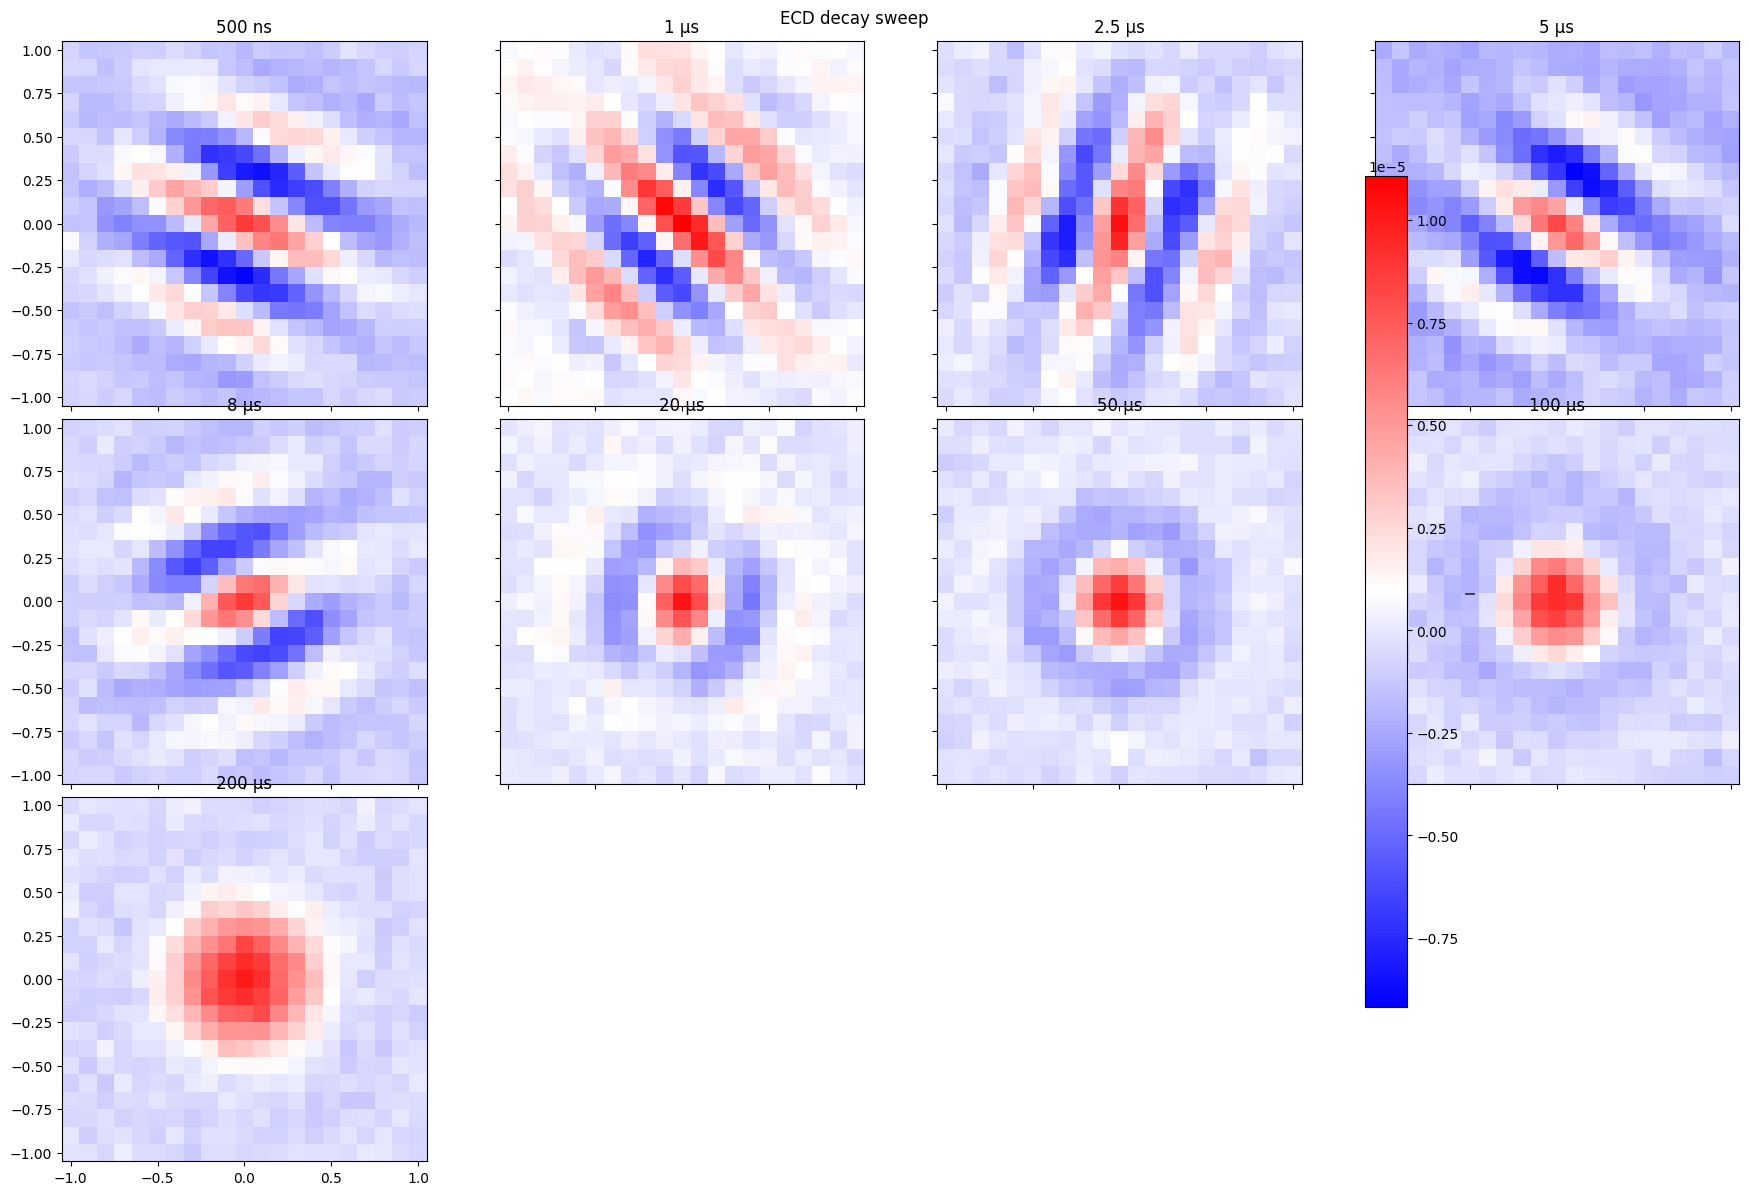

In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================================
# Load all data
# ==========================================================
state_list = []
x_list = []
y_list = []
filename_list = []

vmin = np.inf
vmax = -np.inf

for decay, file_path in zip(decay_sweep_sorted, collected_files_sorted):

    with h5py.File(file_path, "r") as data:

        state = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)
    filename_list.append(os.path.basename(file_path))

    vmin = min(vmin, state.min())
    vmax = max(vmax, state.max())

# ==========================================================
# Save everything
# ==========================================================
np.savez(
    "ECD_decay_sweep_sorted.npz",
    decay=decay_sweep_sorted,
    filenames=np.array(filename_list),
    states=np.array(state_list),
    x=np.array(x_list),
    y=np.array(y_list),
)

print("Saved ECD_decay_sweep_sorted.npz")

# ==========================================================
# Plot
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 12),
    sharex=True,
    sharey=True,
)

axes = np.ravel(axes)

for i in range(num_plots):

    im = axes[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
    )

    decay = decay_sweep_sorted[i]

    if decay >= 1000:
        label = f"{decay/1000:g} μs"
    else:
        label = f"{decay:g} ns"

    axes[i].set_title(label)
    axes[i].set_aspect("equal")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.colorbar(im, ax=axes[:num_plots], shrink=0.9, label="I")

plt.suptitle("ECD decay sweep")
plt.tight_layout()
plt.show()

Files:
['12-11-32_ECD_decay_sweep.hdf5' '12-35-17_ECD_decay_sweep.hdf5'
 '12-59-05_ECD_decay_sweep.hdf5' '13-22-52_ECD_decay_sweep.hdf5'
 '13-46-46_ECD_decay_sweep.hdf5' '14-10-43_ECD_decay_sweep.hdf5'
 '14-35-03_ECD_decay_sweep.hdf5' '15-00-15_ECD_decay_sweep.hdf5'
 '15-26-58_ECD_decay_sweep.hdf5']


C:\Users\qcrew\AppData\Local\Temp\ipykernel_28220\198392715.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


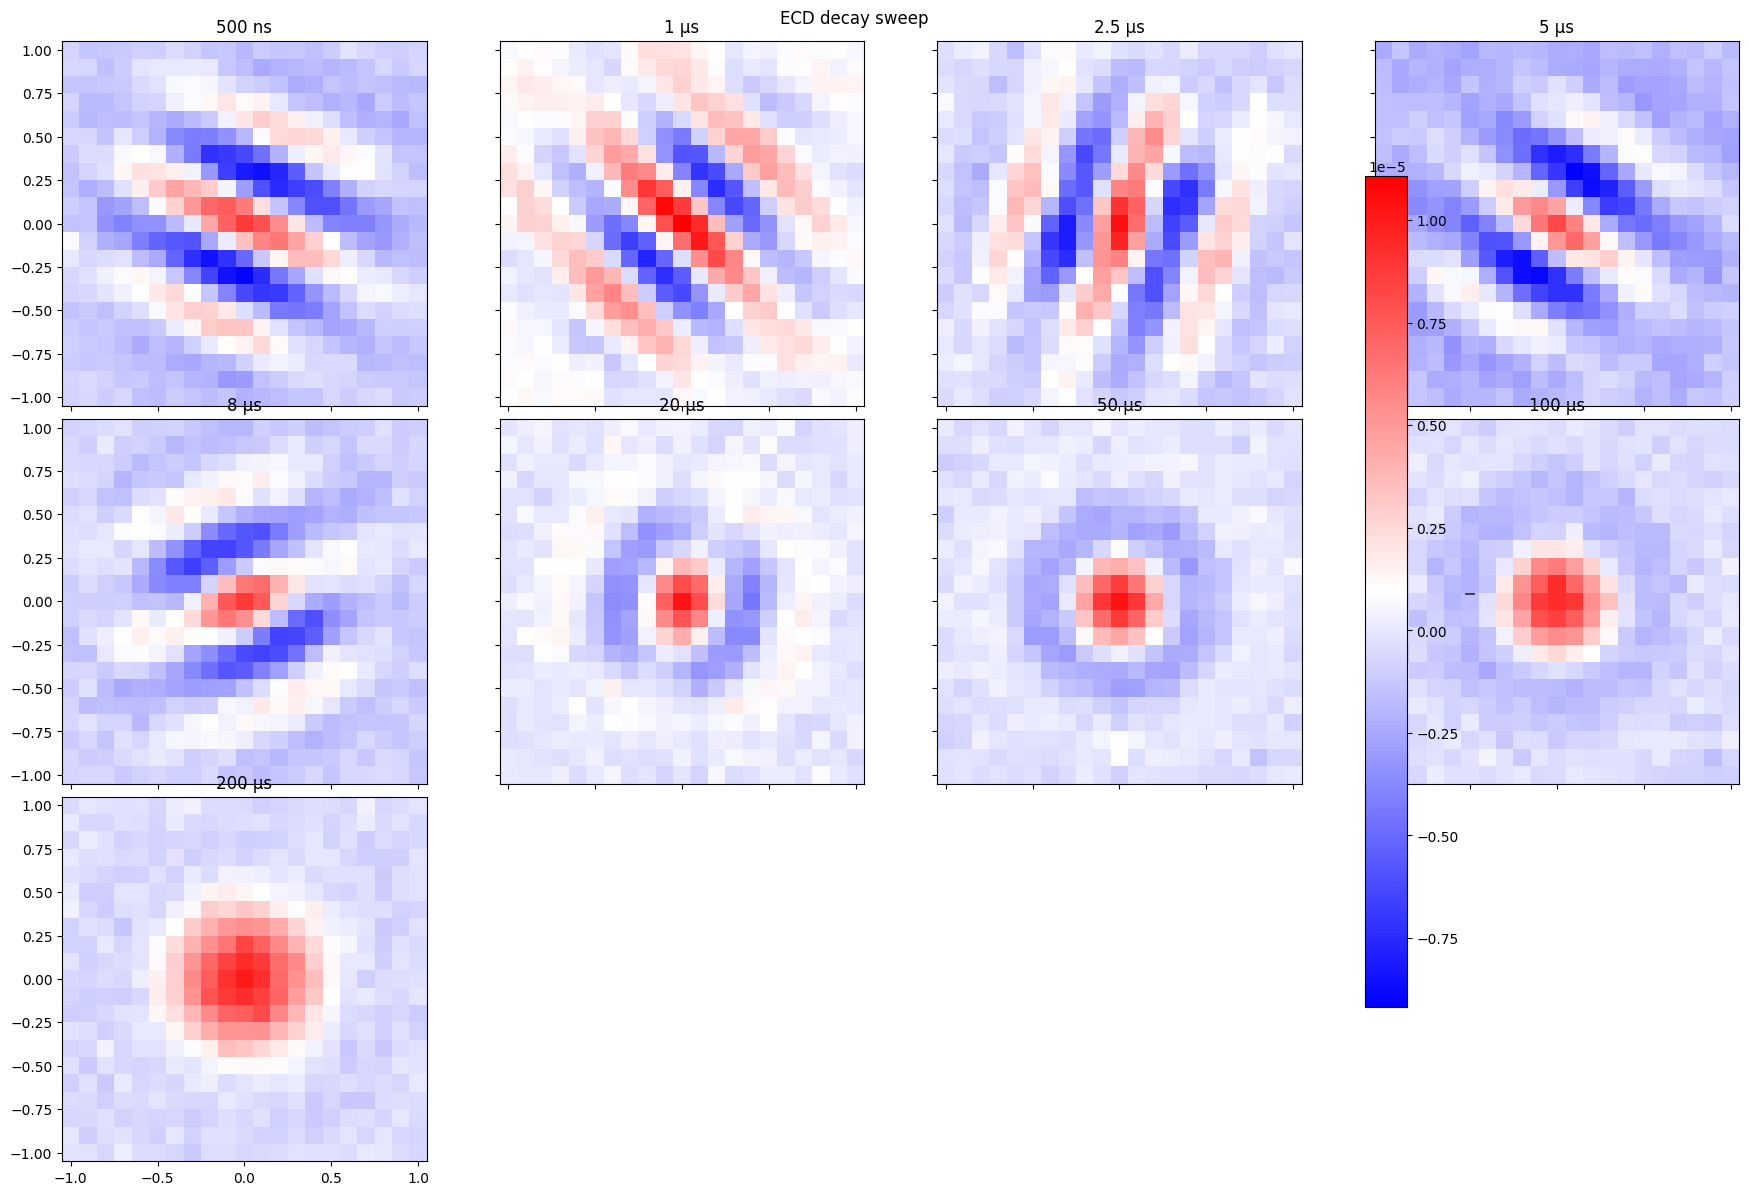

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load NPZ
# ==========================================================
data = np.load("ECD_decay_sweep_sorted.npz", allow_pickle=True)

decay = data["decay"]
filename_list = data["filenames"]
state_list = data["states"]
x_list = data["x"]
y_list = data["y"]

print("Files:")
print(filename_list)

# ==========================================================
# Determine common color scale
# ==========================================================
vmin = np.min(state_list)
vmax = np.max(state_list)

# ==========================================================
# Plot
# ==========================================================
num_plots = len(state_list)

cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 12),
    sharex=True,
    sharey=True,
)

axes = np.ravel(axes)

for i in range(num_plots):

    im = axes[i].pcolormesh(
        x_list[i],
        y_list[i],
        state_list[i],
        shading="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
    )

    if decay[i] >= 1000:
        label = f"{decay[i]/1000:g} μs"
    else:
        label = f"{decay[i]:g} ns"

    axes[i].set_title(label)
    axes[i].set_aspect("equal")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

fig.colorbar(im, ax=axes[:num_plots], shrink=0.9, label="I")

plt.suptitle("ECD decay sweep")
plt.tight_layout()
plt.show()

In [5]:
## fitting

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-11-32_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 2.914044331253223 B -0.12286114271610084 C 2.3949598048131153 alpha 5.187559127624709 theta -0.42297485570975507
sig1 0.4122769958506546 sig2 0.45957234236833483
sig1: 0.41, sig2: 0.46
|a|: 5.188, theta: -0.423
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-11-32_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.0673185390897888


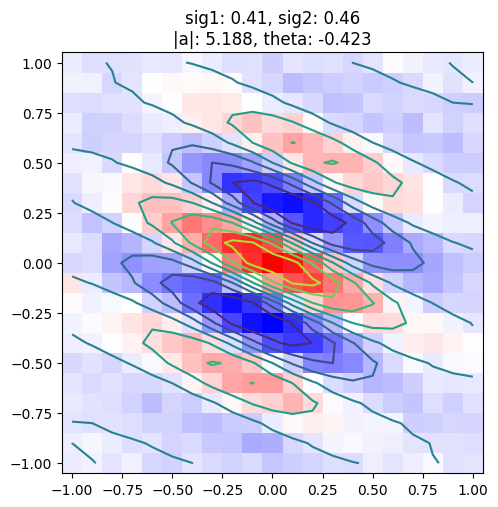

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-35-17_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 2.9219472151904986 B -0.42593892134218375 C 2.5757856860560175 alpha 5.219163329077443 theta -0.790499902536515
sig1 0.3947528738989743 sig2 0.4673606876545551
sig1: 0.39, sig2: 0.47
|a|: 5.219, theta: -0.790
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-35-17_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.1258119670023479


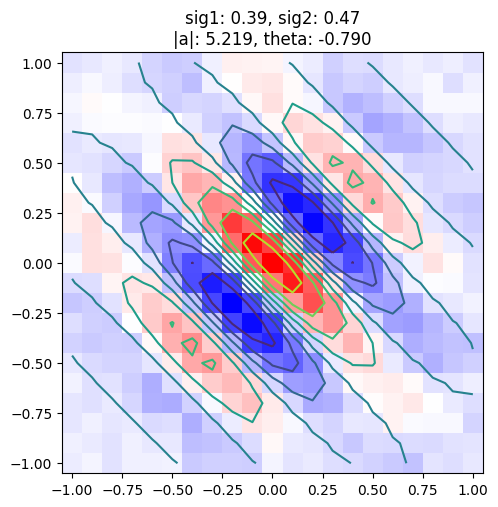

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-59-05_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 2.4084029231248856 B 0.11880384255732605 C 2.664179440823732 alpha 5.148736099996007 theta -1.8936607323248849
sig1 0.46011817943289746 sig2 0.42946966435639816
sig1: 0.46, sig2: 0.43
|a|: 5.149, theta: -1.894
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\12-59-05_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.301385466088524


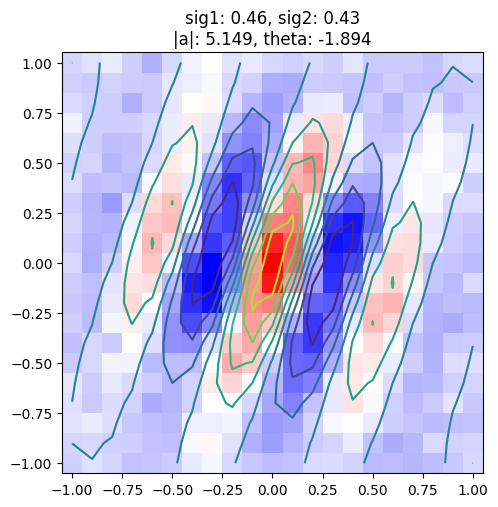

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\13-22-52_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 3.635358633144694 B -0.49705817707398325 C 3.0003543279539775 alpha 4.945010627627622 theta -0.5669311970132478
sig1 0.3577060806211718 sig2 0.42811360131424103
sig1: 0.36, sig2: 0.43
|a|: 4.945, theta: -0.567
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\13-22-52_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.0902299023976636


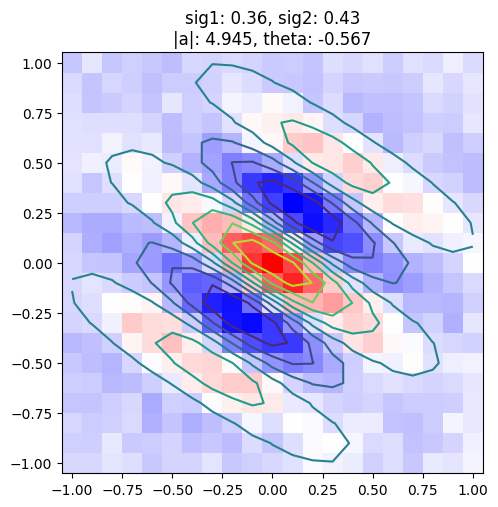

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\13-46-46_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 4.320903672478427 B 0.4726470475672569 C 2.6746716856202104 alpha 4.876076301334492 theta 0.397379046326998
sig1 0.33531557250248245 sig2 0.4429271216496851
sig1: 0.34, sig2: 0.44
|a|: 4.876, theta: 0.397
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\13-46-46_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  0.936755160495915


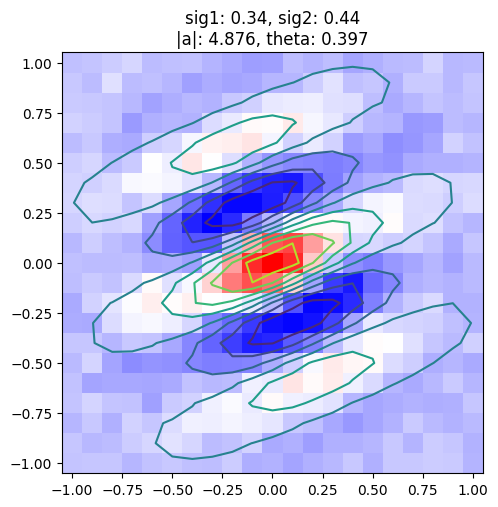

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\14-10-43_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 3.6971799767829876 B 0.49999999999999994 C 4.999999999999999 alpha 4.382999376671382 theta 1.1573804890414254
sig1 0.3764930576491129 sig2 0.310992153935417
sig1: 0.38, sig2: 0.31
|a|: 4.383, theta: 1.157
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\14-10-43_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  0.815797174130942


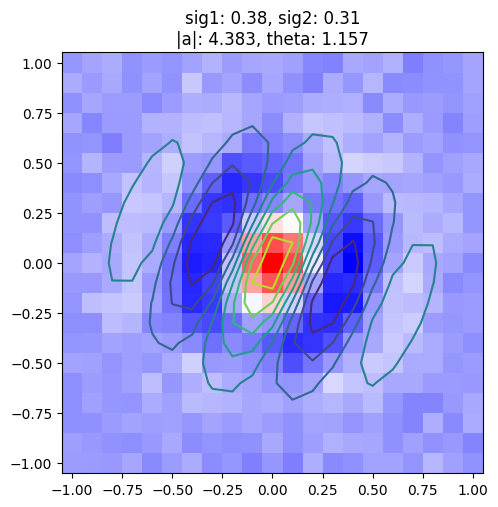

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\14-35-03_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 4.999999999999999 B -0.49999999999999994 C 4.999999999999999 alpha 3.2494604516710925 theta -0.6102160124960025
sig1 0.3015113445777637 sig2 0.33333333333333337
sig1: 0.30, sig2: 0.33
|a|: 3.249, theta: -0.610
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\14-35-03_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.0971188947425645


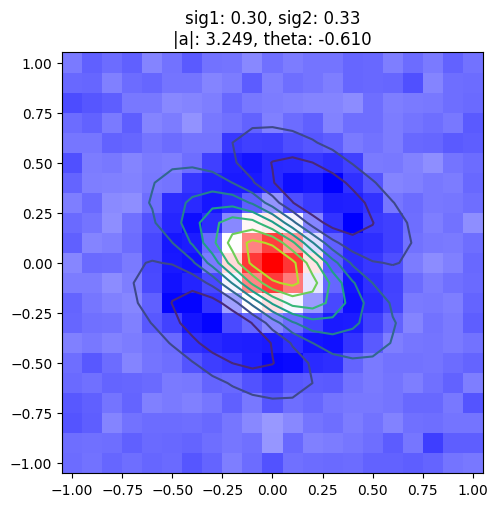

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\15-00-15_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 4.999999999999999 B -0.49999999999999994 C 4.999999999999999 alpha 2.1397954508278225 theta -0.46695194334055246
sig1 0.3015113445777637 sig2 0.33333333333333337
sig1: 0.30, sig2: 0.33
|a|: 2.140, theta: -0.467
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\15-00-15_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  1.0743177099690155


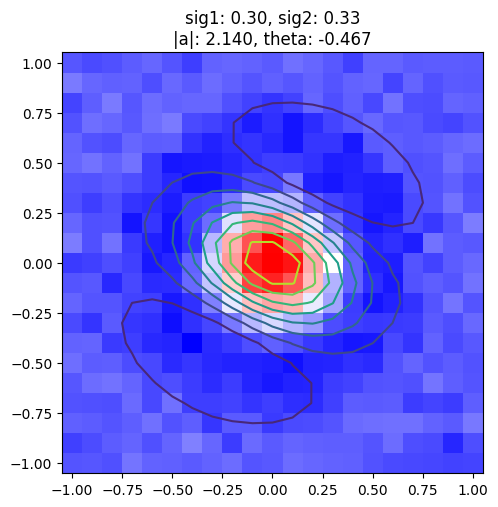

C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\15-26-58_ECD_decay_sweep.hdf5
(441, 2) (441,)
state_fit (21, 21)
A 4.134901511751453 B 0.03243981513057705 C 4.999998118153185 alpha 1.9732415774854943 theta 0.02365756514979194
sig1 0.34778930245921214 sig2 0.31618941910312676
sig1: 0.35, sig2: 0.32
|a|: 1.973, theta: 0.024
C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06\15-26-58_ECD_decay_sweep.hdf5
tomo_phase =  1-theta/2/np.pi =  0.9962347815648921


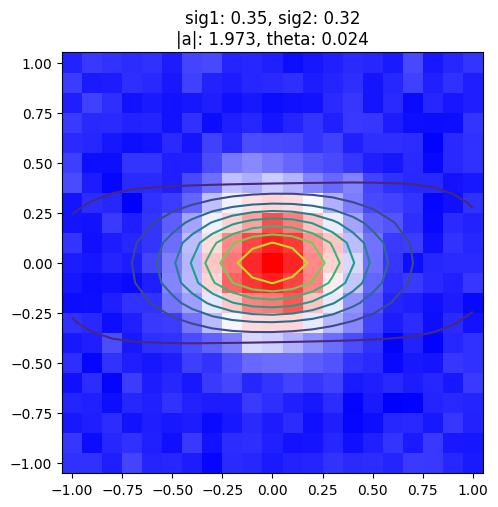

In [6]:
from re import X
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
from scipy.optimize import curve_fit
import numpy.linalg as LA

def reshape_and_avg(data_array, buffer):
    return np.average(np.reshape(data_array, buffer), axis=0)


def correct_ofs_and_amp(data_array, amp, ofs):
    return (data_array - ofs) / amp


def gaussian(x, a, b, sigma, c):
    return a * np.exp(-((x - b) ** 2) / (2 * sigma ** 2)) + c


def gaussian_fit(x, y):
    mean_arg = np.argmax(y)
    mean = x[mean_arg]
    # fit_range = int(0.2 * len(x))
    x_sample = x  # [mean_arg - fit_range : mean_arg + fit_range]
    y_sample = y  # [mean_arg - fit_range : mean_arg + fit_range]
    popt, pcov = curve_fit(
        gaussian,
        x_sample,
        y_sample,
        bounds=(
            (-np.inf, min(x_sample), -np.inf, -np.inf),
            (np.inf, max(x_sample), np.inf, np.inf),
        ),
        p0=[max(y) - min(y), 0, 0.5, max(y)],
    )
    return popt

def characteristic_coherent(xy, A, B, C, alpha, theta, S, c):
    x, y = xy[:, 0], xy[:, 1]
    # Gaussian Envelope
    envelope = np.exp(-(A * x**2 + 2 * B * x * y + C * y**2))
    # Interference term: theta is displacement angle
    # Oscillations appear along the axis defined by (y*cos - x*sin)
    oscillation = np.real(np.exp(2j * alpha * (y * np.cos(theta) - x * np.sin(theta))))
    return S * envelope * oscillation + c

tau_fit_list = []
alpha_fit_list = []
for i in range(len(paired_data)):
    char2d_filename = paired_data[i][1]
    tau = paired_data[i][0]
    print(char2d_filename)
    
    with h5py.File(char2d_filename, "r") as data:
        state_corrected = np.mean(np.array(data["I"]), axis=0)
        x = np.array(data["ampx_x"])
        y = np.array(data["ampx_y"])

        # Get fit
        x_mesh, y_mesh = np.meshgrid(x, y)
        xdata = np.transpose([x_mesh.flatten(), y_mesh.flatten()])
        ydata = np.array(state_corrected.flatten())
        print(xdata.shape,ydata.shape)
        bounds = [
        ( 0.0, -0.5, 0.0, 0, int(np.pi/180 * (-180)),-0.1, np.min(state_corrected)),
        ( 5, 0.5, 5, 6, int(np.pi/180 * (185)),0.1, np.max(state_corrected)),
        ]  # (_, A, B, C, alpha, theta)
        guess = ( 2, 0, 2, 4, np.pi/180*0,-0.01, np.mean(state_corrected) )

        popt, pcov = curve_fit(
        characteristic_coherent,
        xdata,
        ydata,
        bounds=bounds,
        p0=guess,
        )
        state_fit = characteristic_coherent(xdata, *popt).reshape(len(y), len(x))
        print("state_fit", state_fit.shape)
        # Final plot and fit
        fig, ax = plt.subplots()

        # print(popt)
        print("A",popt[0], "B",popt[1], "C",popt[2], "alpha",popt[3], "theta", popt[4])
        ax.set_aspect("equal", "box")
        fig.tight_layout()
#         sm = ax.imshow(state_fit, cmap=plt.get_cmap("coolwarm"), origin="lower")
        A, B, C = popt[:3]
        cov_matrix = np.array([[A, B], [B, C]])
        lamb1, lamb2 = LA.eig(cov_matrix)[0]
        sig1, sig2 = 1 / (2 * lamb1) ** 0.5, 1 / (2 * lamb2) ** 0.5
        print("sig1", sig1, "sig2", sig2)
        label_txt = (
        f"sig1: {sig1:.2f}, sig2: {sig2:.2f}\n|a|: {popt[3]:.3f}, theta: {popt[4]:.3f}"
        )
        print(label_txt)
        CS = ax.contour(x_mesh, y_mesh, state_fit, levels=np.linspace(np.min(state_fit),np.max(state_fit),10))
        im = ax.pcolormesh(
        x,
        y,
        state_corrected,
#         norm=colors.Normalize(vmin=-1, vmax=1),
        cmap="bwr",
        )
        plt.title(label_txt)
        print(char2d_filename)
        print("tomo_phase =  1-theta/2/np.pi = ", 1-popt[4]/2/np.pi)
        plt.show()
        alpha_fit_list.append(popt[3])        
        tau_fit_list.append(tau)

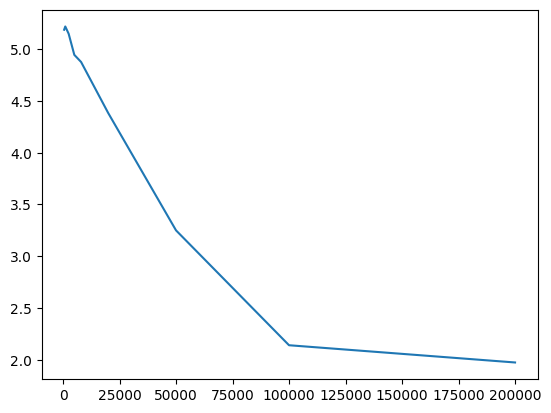

In [7]:
plt.plot(tau_fit_list, alpha_fit_list)

In [8]:
import numpy as np

data = np.load("ECD_decay_sweep_sorted.npz", allow_pickle=True)

decays = data["decay"]
filenames = data["filenames"]
states = data["states"]
x_all = data["x"]
y_all = data["y"]

print(data.files)
print(states.shape)

['decay', 'filenames', 'states', 'x', 'y']
(9, 21, 21)


12-11-32_ECD_decay_sweep.hdf5
A      = 2.9170
B      = -0.1230
C      = 2.3948
|alpha|= 5.1875
theta  = -0.4229 rad
sig1   = 0.412
sig2   = 0.460
tomo_phase = 1.0673
12-35-17_ECD_decay_sweep.hdf5
A      = 2.9228
B      = -0.4265
C      = 2.5761
|alpha|= 5.2191
theta  = -0.7905 rad
sig1   = 0.395
sig2   = 0.467
tomo_phase = 1.1258
12-59-05_ECD_decay_sweep.hdf5
A      = 2.4093
B      = 0.1163
C      = 2.6715
|alpha|= 5.1489
theta  = -1.8938 rad
sig1   = 0.460
sig2   = 0.429
tomo_phase = 1.3014
13-22-52_ECD_decay_sweep.hdf5
A      = 3.6397
B      = -0.4970
C      = 2.9993
|alpha|= 4.9450
theta  = -0.5670 rad
sig1   = 0.358
sig2   = 0.428
tomo_phase = 1.0902
13-46-46_ECD_decay_sweep.hdf5
A      = 4.3222
B      = 0.4727
C      = 2.6753
|alpha|= 4.8760
theta  = 0.3974 rad
sig1   = 0.335
sig2   = 0.443
tomo_phase = 0.9368
14-10-43_ECD_decay_sweep.hdf5
A      = 3.6965
B      = 0.5000
C      = 5.0000
|alpha|= 4.3830
theta  = 1.1575 rad
sig1   = 0.377
sig2   = 0.311
tomo_phase = 0.8158
14-35-03_

C:\Users\qcrew\AppData\Local\Temp\ipykernel_28220\1109552512.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


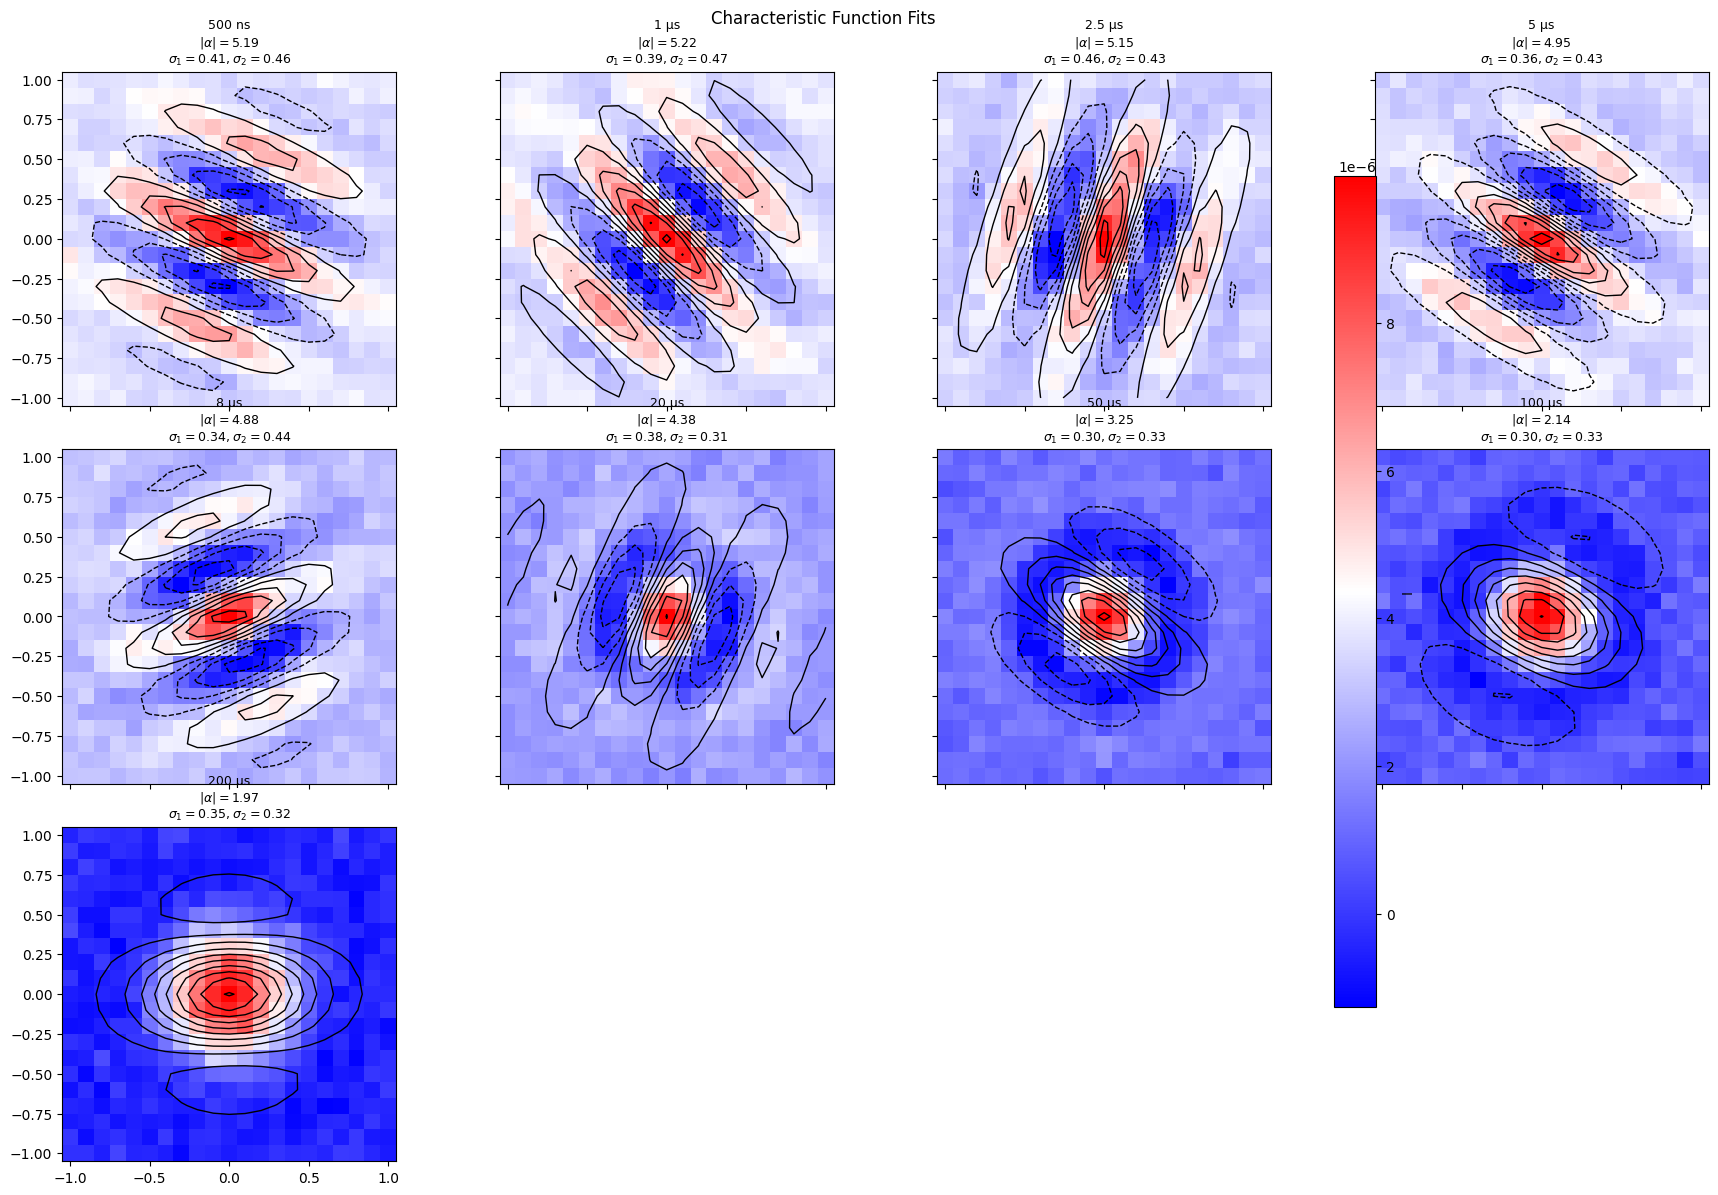

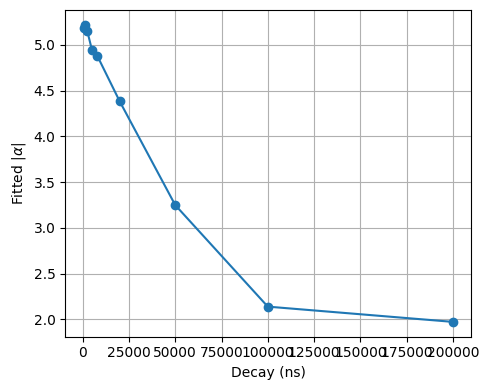

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as LA
from scipy.optimize import curve_fit

# ==========================================================
# Fit all characteristic functions
# ==========================================================

alpha_fit_list = []
tau_fit_list = []

n = len(states)

cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 12),
    sharex=True,
    sharey=True,
)

axes = np.ravel(axes)

for i, (state_corrected, x, y, tau, fname) in enumerate(
    zip(states, x_all, y_all, decays, filenames)
):

    x_mesh, y_mesh = np.meshgrid(x, y)

    xdata = np.column_stack((x_mesh.ravel(), y_mesh.ravel()))
    ydata = state_corrected.ravel()

    bounds = (
        (
            0.0,
            -0.5,
            0.0,
            0.0,
            np.deg2rad(-180),
            -0.1,
            np.min(state_corrected),
        ),
        (
            5.0,
            0.5,
            5.0,
            6.0,
            np.deg2rad(185),
            0.1,
            np.max(state_corrected),
        ),
    )

    guess = (
        2,
        0,
        2,
        4,
        0,
        -0.01,
        np.mean(state_corrected),
    )

    popt, _ = curve_fit(
        characteristic_coherent,
        xdata,
        ydata,
        p0=guess,
        bounds=bounds,
    )

    state_fit = characteristic_coherent(
        xdata,
        *popt,
    ).reshape(len(y), len(x))

    # ------------------------------------------------------
    # Calculate sigma
    # ------------------------------------------------------
    A, B, C = popt[:3]

    cov_matrix = np.array([[A, B], [B, C]])

    eigvals = np.real(LA.eigvals(cov_matrix))

    sig1 = 1 / np.sqrt(2 * eigvals[0])
    sig2 = 1 / np.sqrt(2 * eigvals[1])

    alpha_fit_list.append(popt[3])
    tau_fit_list.append(tau)

    print("=" * 60)
    print(fname)
    print(f"A      = {popt[0]:.4f}")
    print(f"B      = {popt[1]:.4f}")
    print(f"C      = {popt[2]:.4f}")
    print(f"|alpha|= {popt[3]:.4f}")
    print(f"theta  = {popt[4]:.4f} rad")
    print(f"sig1   = {sig1:.3f}")
    print(f"sig2   = {sig2:.3f}")
    print(f"tomo_phase = {1 - popt[4]/(2*np.pi):.4f}")

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    ax = axes[i]

    im = ax.pcolormesh(
        x,
        y,
        state_corrected,
        cmap="bwr",
        shading="auto",
    )

    ax.contour(
        x_mesh,
        y_mesh,
        state_fit,
        colors="k",
        levels=10,
        linewidths=1,
    )

    ax.set_aspect("equal")

    if tau >= 1000:
        tau_label = f"{tau/1000:g} μs"
    else:
        tau_label = f"{tau:g} ns"

    ax.set_title(
        tau_label
        + "\n"
        + rf"$|\alpha|={popt[3]:.2f}$"
        + "\n"
        + rf"$\sigma_1={sig1:.2f}$"
        + ", "
        + rf"$\sigma_2={sig2:.2f}$",
        fontsize=9,
    )

# Remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

fig.colorbar(
    im,
    ax=axes[:n],
    shrink=0.9,
    label="I",
)

plt.suptitle("Characteristic Function Fits")
plt.tight_layout()
plt.show()

# ==========================================================
# Plot fitted alpha vs decay
# ==========================================================

plt.figure(figsize=(5,4))
plt.plot(tau_fit_list, alpha_fit_list, "o-")
plt.xlabel("Decay (ns)")
plt.ylabel(r"Fitted $|\alpha|$")
plt.grid(True)
plt.tight_layout()
plt.show()

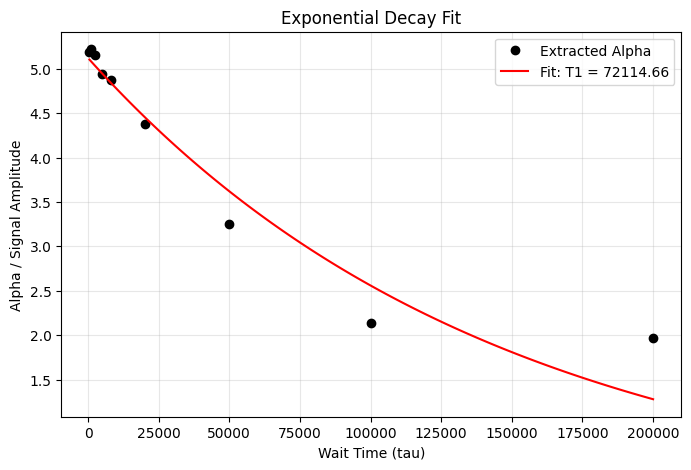

Decay Constant (T1): 72114.66ns


In [10]:
from scipy.optimize import curve_fit

# 1. Define the exponential decay function
# t: time (tau), A: amplitude, T1: decay constant, offset: baseline
def exp_decay(t, A, T1):
    return A * np.exp(-t / (2*T1))

# 2. Prepare your data
# Ensure they are numpy arrays and in the same units (e.g., microseconds)
x_data = np.array(tau_fit_list)#[2:] 
y_data = np.array(alpha_fit_list)#[2:]

# 3. Initial Guess (Crucial for convergence)
# A: peak to peak, T1: middle of your time range, offset: last data point
guess_A = y_data[0] - y_data[-1]
guess_T1 = np.median(x_data)
p0 = [guess_A, guess_T1]

# 4. Perform the fit
try:
    popt, pcov = curve_fit(exp_decay, x_data, y_data, p0=p0)
    A_fit, T1_fit = popt
    
    # Generate smooth curve for plotting
    tau_fine = np.linspace(min(x_data), max(x_data), 100)
    alpha_smooth = exp_decay(tau_fine, *popt)

    # 5. Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x_data, y_data, 'ko', label='Extracted Alpha')
    plt.plot(tau_fine, alpha_smooth, 'r-', label=f'Fit: T1 = {T1_fit:.2f}')
    
    plt.xlabel("Wait Time (tau)")
    plt.ylabel("Alpha / Signal Amplitude")
    plt.title("Exponential Decay Fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Decay Constant (T1): {T1_fit:.2f}ns")

except Exception as e:
    print(f"Fitting failed: {e}")